In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


NumPy Time: 0.06587743759155273
TensorFlow Time: 0.19692230224609375


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


## Task 1: Data Preparation

### Loading the Data
- The dataset is loaded from Google Drive.
- Images are converted to grayscale and resized to 28x28.
- Pixel values are normalized to the range [0,1].
- Labels are extracted from folder names and one-hot encoded.

Load and Preprocess the Devnagari Digit Dataset

In [10]:
train_dir = "/content/drive/MyDrive/AI_ML/Week4/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/AI_ML/Week4/DevanagariHandwrittenDigitDataset/Test/"

img_height, img_width = 28, 28
num_classes = 10

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img, dtype=np.float32) / 255.0

                images.append(img)
                labels.append(label)
            except:
                print(f"Skipping file: {img_path}")

    return np.array(images), np.array(labels), class_names

Load Training and Testing Data

In [11]:
x_train, y_train, train_class_names = load_images_from_folder(train_dir)
x_test, y_test, test_class_names = load_images_from_folder(test_dir)

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (17000, 28, 28)
Training labels shape: (17000,)
Testing images shape: (3000, 28, 28)
Testing labels shape: (3000,)


Reshape Images for Keras

In [12]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

One-Hot Encode Labels

In [13]:
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print("One-hot training labels shape:", y_train.shape)
print("One-hot testing labels shape:", y_test.shape)

One-hot training labels shape: (17000, 10)
One-hot testing labels shape: (3000, 10)


Visualize Sample Images

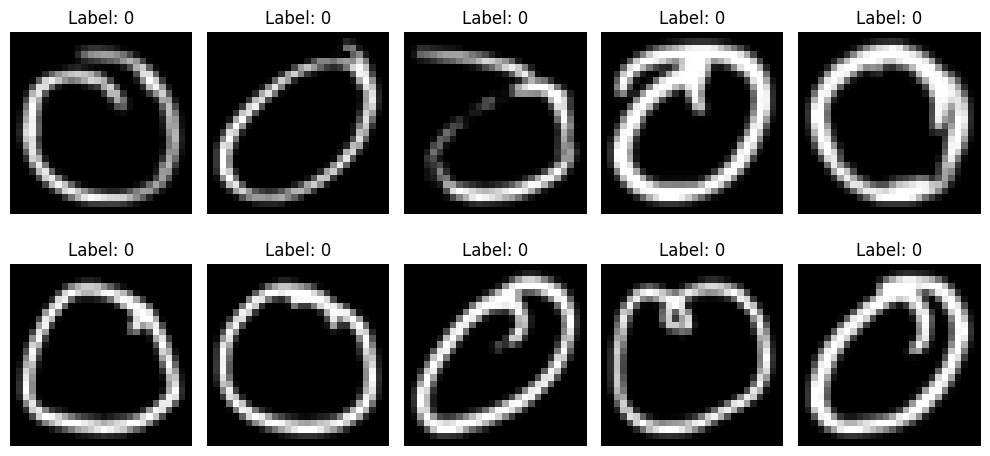

In [14]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2: Build the FCN Model

### Model Architecture
- Input Layer
- Flatten Layer
- Hidden Layers:
  - 64 neurons (sigmoid)
  - 128 neurons (sigmoid)
  - 256 neurons (sigmoid)
- Output Layer:
  - 10 neurons (softmax)

Build the Fully Connected Neural Network


In [15]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy

Compile the Model

In [17]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Task 4: Train the Model

- Batch size: 128
- Epochs: 20
- Validation split: 0.2
- Callbacks:
  - ModelCheckpoint
  - EarlyStopping

Train the Model

In [19]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,

    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7325 - loss: 0.8226
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7776 - loss: 0.6546 - val_accuracy: 0.0000e+00 - val_loss: 8.0202
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8718 - loss: 0.3647
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8928 - loss: 0.3304 - val_accuracy: 0.0000e+00 - val_loss: 8.6433
Epoch 3/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9327 - loss: 0.2351
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9387 - loss: 0.2153 - val_accuracy: 0.0000e+00 - val_loss: 9.1654
Epoch 4/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9532 - loss: 0.1673
Epoch 4: val_accuracy did not i

Plot Training and Validation Accuracy / Loss

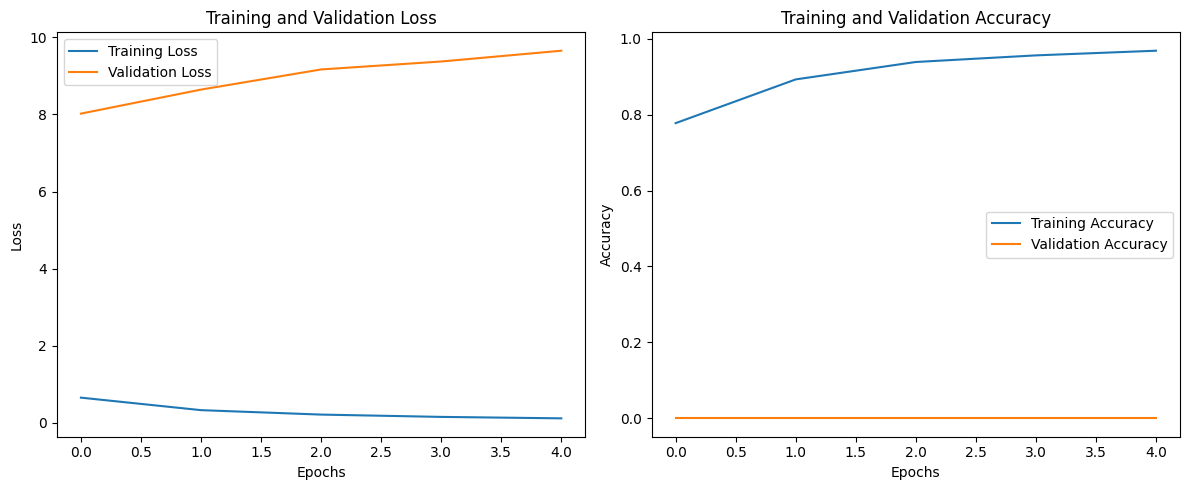

In [20]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

The trained model is evaluated on the test dataset to measure its performance.

Evaluate the Model on Test Set

In [21]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 1s - 6ms/step - accuracy: 0.6603 - loss: 1.9429
Test Loss: 1.9429
Test Accuracy: 0.6603


## Task 6: Save and Load the Model

The trained model is saved as an .h5 file and reloaded for verification.

Save the Model

In [29]:
model.save("/content/drive/MyDrive/AI_ML/Week4/devnagari_fcn_model.h5")
print("Model saved successfully.")

Model saved successfully.


Load the Saved Model

In [30]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/AI_ML/Week4/devnagari_fcn_model.h5")
print("Model loaded successfully.")

Model loaded successfully.


Re-evaluate the Loaded Model

In [31]:
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

94/94 - 1s - 6ms/step - accuracy: 0.6603 - loss: 1.9429
Loaded Model Test Loss: 1.9429
Loaded Model Test Accuracy: 0.6603


## Task 7: Predictions

Predictions are made using the trained model and converted into class labels.

In [32]:
# Make predictions on test data
predictions = model.predict(x_test)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Compare first prediction
print("Predicted label for first image:", predicted_labels[0])
print("True label for first image:", np.argmax(y_test[0]))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0


Display some predictions

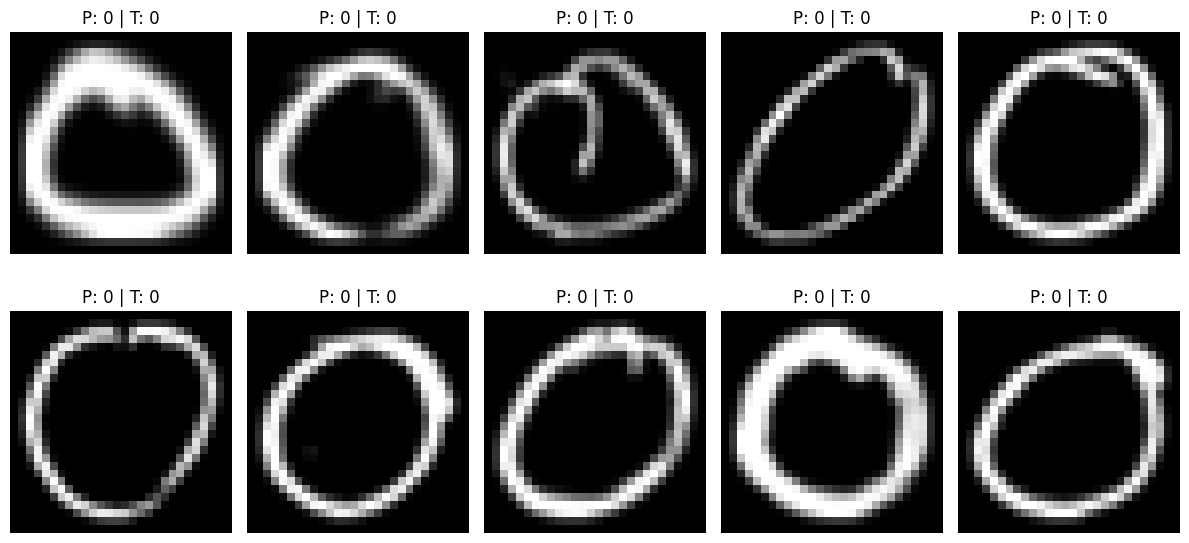

In [34]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"P: {predicted_labels[i]} | T: {np.argmax(y_test[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion

In this worksheet, a Fully Connected Neural Network (FCN) was implemented using Keras for Devnagari digit classification. The dataset was preprocessed, the model was trained and evaluated, and predictions were generated successfully. The model was also saved and reloaded for reuse.